In [4]:
from __future__ import annotations

import pathlib

import polars
import seaborn
from matplotlib import pyplot as plt

_ = polars.Config.set_tbl_rows(100)

In [5]:
def load_data(directory: pathlib.Path) -> polars.DataFrame:
    dfs = []
    for run in directory.glob('**/results.csv'):
        try:
            df = polars.read_csv(run)
            if len(df) > 0:
                dfs.append(df)
        except Exception as e:
            print(f'Error loading {run}... skipping: {e}')
    return polars.concat(dfs)

In [6]:
data = load_data(pathlib.Path('../data/bench/remote-invocation-v1/'))
results = data
results

framework,trials,state_size_bytes,mean_latency_s,stdev_latency_s
str,i64,i64,f64,f64
"""Academy""",30,1000000000,0.034662,0.005536
"""Academy""",30,2000000000,0.034493,0.002062
"""Academy""",30,4000000000,0.033973,0.00195
"""Academy""",30,8000000000,0.034172,0.005599
"""Academy""",30,16000000000,0.033608,0.005562
"""Globus Compute""",30,1000000000,1.22682,0.313165
"""Globus Compute""",30,2000000000,1.694308,0.245858
"""Globus Compute""",30,4000000000,2.478871,0.414004
"""Globus Compute""",30,8000000000,4.099777,0.297275


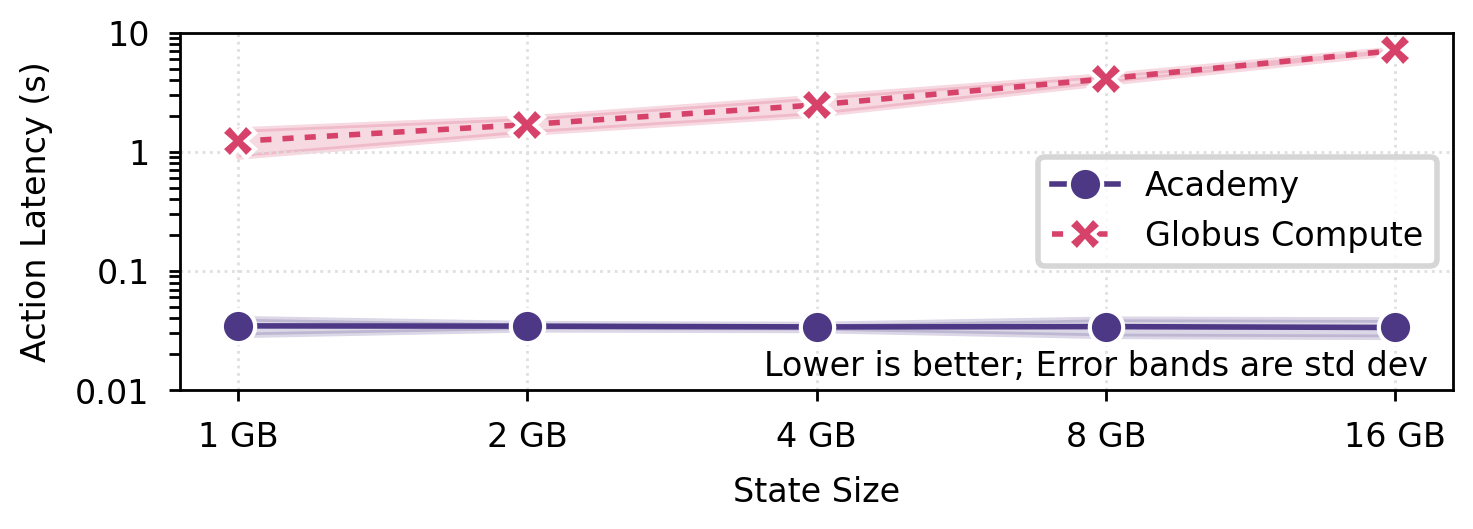

In [10]:
fig, axs = plt.subplots(1, 1)

xticks = sorted(set(results['state_size_bytes'].to_list()))
xtick_labels = ['1 GB', '2 GB', '4 GB', '8 GB', '16 GB']
yticks = [0.01, 0.1, 1, 10]

dashes = {'Globus Compute': (2, 2), 'Academy': ()}
markers = {'Globus Compute': 'X', 'Academy': 'o'}
palette = {'Globus Compute': '#D64269', 'Academy': '#4D3886'}

handle = seaborn.lineplot(
    results,
    x='state_size_bytes',
    y='mean_latency_s',
    hue='framework',
    hue_order=['Globus Compute', 'Academy'],
    style='framework',
    dashes=dashes,
    markers=markers,
    palette=palette,
    ax=axs,
)

for i, name in enumerate(['Globus Compute', 'Academy']):
    subset = results.filter(polars.col('framework') == name)
    x = subset['state_size_bytes']
    y = subset['mean_latency_s']
    err = subset['stdev_latency_s']
    color = axs.get_lines()[i].get_c()

    lower = y - err
    upper = y + err
    axs.fill_between(x, lower, upper, alpha=0.2, color=color)


handles, _ = axs.get_legend_handles_labels()
axs.legend(
    handles=handles[::-1],
    title=None,
    labels=['Academy', 'Globus Compute'],
)
_ = handle.set(
    xscale='log',
    yscale='log',
    xlabel='State Size',
    ylabel='Action Latency (s)',
)
handle.set_xticks(xticks, minor=False)
handle.set_xticklabels(xtick_labels)
axs.tick_params(axis='x', which='minor', bottom=False)
handle.set_yticks(yticks, minor=False)
handle.set_yticklabels([str(y) for y in yticks])

axs.annotate(
    'Lower is better; Error bands are std dev',
    xy=(0.98, 0.02),
    xycoords=('axes fraction'),
    ha='right',
    va='bottom',
)

fig.tight_layout()
plt.draw()
fig.set_size_inches(3.5, 1)
fig.savefig('figures/action-latency-vs-stateless.pdf')